# Course NIGK21007U - Integrated Water Resources Modelling
## Tutorial 2

This notebook shows you how to visualize and analyze results from the Mike SHE vegetation-vadose zone model you built in Tutorial 2.

First, load all necessary packages:

In [1]:
import mikeio
from mikeio import Dfs3
from mikeio import Dfs2
import matplotlib.pyplot as plt
import numpy as np

Give name and path to dfs3 output file:

In [2]:
my_file_name = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Tutorials\Tutorial_2\Vegetation_Vadose_Model\VV_Model.she - Result Files\VV_Model_3DUZ.dfs3'

Open the file and print some info:

In [3]:
# Open the file to get a Dfs3 object (metadata is available but data isn't loaded yet)
dfs = Dfs3(my_file_name)

# Inspect file properties (e.g., number of time steps, items)
print(f"Number of time steps: {dfs.n_timesteps}")
print(f"Item names: {[item.name for item in dfs.items]}")

Number of time steps: 32
Item names: ['water content in unsaturated zone', 'root water uptake']


Define the item you are interested in:

In [4]:
my_item = r'water content in unsaturated zone' # define the item you are interested in

Read the item of interest:

In [5]:
# Read the Dataset (ds)
ds = mikeio.read(my_file_name, items=[my_item])
# extract the time indices from the file
time_array_datetime = ds.time.values
unit = repr(ds[my_item].unit) # get the unit - take not of the use of repr here - unit itself may be an internal code

# Get the DataArray for the item of interest
data_array = ds[my_item]
# The shape of the underlying data is (time, z, y, x)
print(data_array.shape) # Example output: (500, 10, 100, 80)

(32, 200, 3, 3)


Make a time series plot:

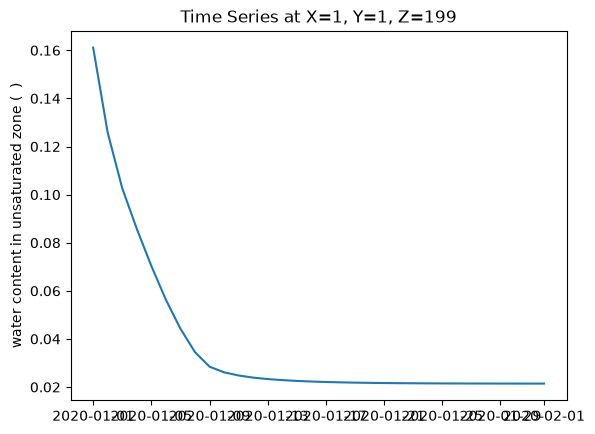

In [6]:
# Define the indices
x_idx = 1 # we always want the center cell, i.e. (1,1)
y_idx = 1
z_idx = 199 # Note that layer 0 is the deepest layer!! Not the first layer from the top!

# Extract the time series using the indices (Time, Z, Y, X)
# The colon `:` for the time axis ensures we get ALL time steps.
time_series_values = data_array.values[:, z_idx, y_idx, x_idx]

fig, ax = plt.subplots()
ax.plot(time_array_datetime, time_series_values)
ax.set_ylabel(f"{my_item}" + ' (' + unit + ')')
ax.set_title(f"Time Series at X={x_idx}, Y={y_idx}, Z={z_idx}")
plt.show()

Make a profile plot for different times. Define time steps to be included:

In [ ]:
mt_idx = [0,10,20,30]

Create the plot:

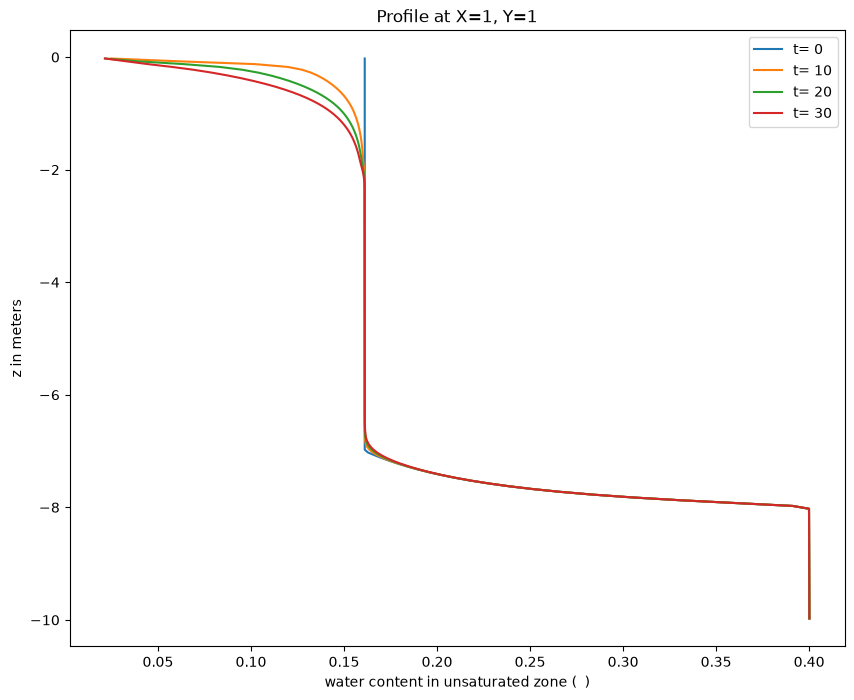

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

for t_idx in mt_idx:

    layer_values = data_array.values[t_idx, :,  y_idx, x_idx]
    
    
    # 1. Get the layer indices (as you successfully did)
    layer_indices = dfs.geometry.z # This returns [0., 1., ..., 199.]
    
    # Need to define physical z-coords manually, this info is not in the dfs file for some reason
    
    physical_z_coords = -0.05*200 + 0.025 + 0.05*layer_indices
      
    
    # Plotting the data. We transpose the Y coordinates to match the (Y, X) data shape
    
    ax.plot(layer_values, physical_z_coords, label = f"t= {t_idx}")
ax.set_xlabel(f"{my_item}" + ' (' + unit + ')')
ax.set_ylabel('z in meters')
ax.set_title(f"Profile at X={x_idx}, Y={y_idx}")
ax.legend()
plt.show()

Now let's look at root water uptake:

(32, 200, 3, 3)


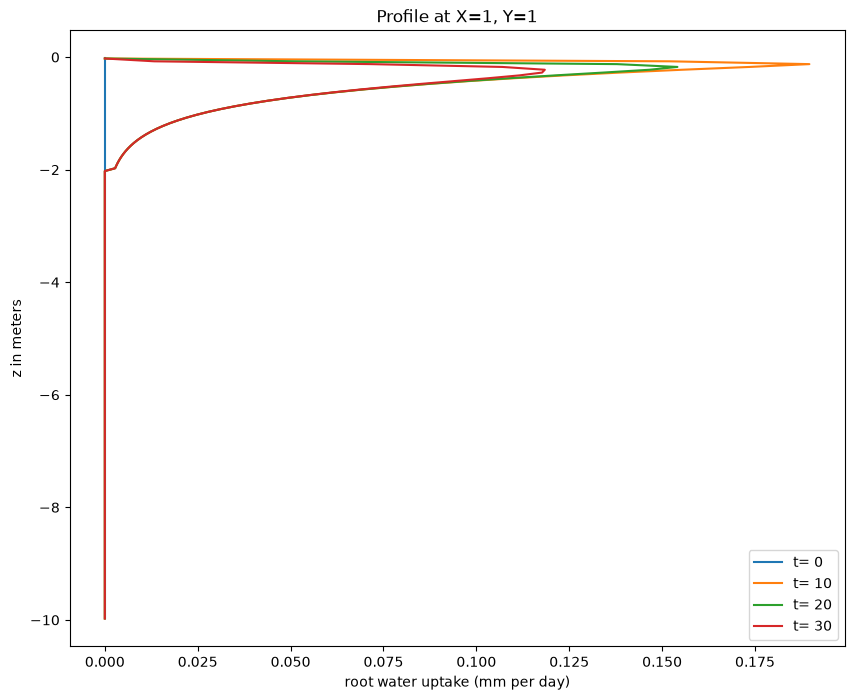

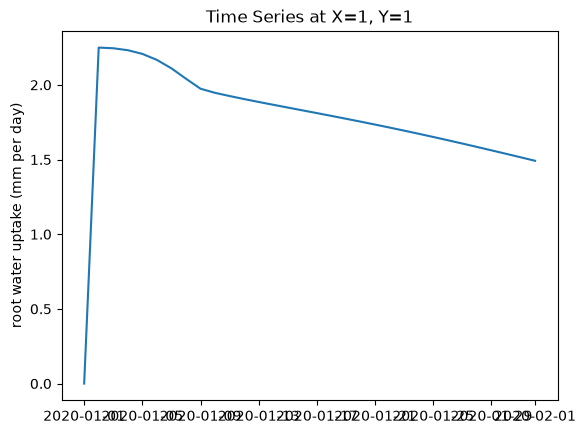

In [9]:
my_item = r'root water uptake' # define the item you are interested in


# Read the Dataset (ds)
ds = mikeio.read(my_file_name, items=[my_item])
# extract the time indices from the file
time_array_datetime = ds.time.values
unit = repr(ds[my_item].unit) # get the unit - take not of the use of repr here - unit itself may be an internal code

# Get the DataArray for the item of interest
data_array = ds[my_item]
# The shape of the underlying data is (time, z, y, x)
print(data_array.shape) # Example output: (500, 10, 100, 80)
#%% Make a profile plot for different times
# Define the indices
fig, ax = plt.subplots(figsize=(10, 8))
mt_idx = [0,10,20,30]

for t_idx in mt_idx:

    layer_values = data_array.values[t_idx, :,  y_idx, x_idx]
    
    
    # 1. Get the layer indices (as you successfully did)
    layer_indices = dfs.geometry.z # This returns [0., 1., ..., 199.]
    
    # Need to define physical z-coords manually, this info is not in the dfs file for some reason
    
    physical_z_coords = -0.05*200 + 0.025 + 0.05*layer_indices
      
    
    # Plotting the data. We transpose the Y coordinates to match the (Y, X) data shape
    
    ax.plot(layer_values, physical_z_coords, label = f"t= {t_idx}")
ax.set_xlabel(f"{my_item}" + ' (' + unit + ')')
ax.set_ylabel('z in meters')
ax.set_title(f"Profile at X={x_idx}, Y={y_idx}")
ax.legend()
plt.show()
#%% Let's plot a time series of total root water uptake
rw_values = data_array.values[:, :,  y_idx, x_idx]
total_rw_uptake = np.sum(rw_values,1)
fig, ax = plt.subplots()
ax.plot(time_array_datetime, total_rw_uptake)
ax.set_ylabel(f"{my_item}" + ' (' + unit + ')')
ax.set_title(f"Time Series at X={x_idx}, Y={y_idx}")
plt.show()

Now let's compare root water uptake and actual evapotranspiration:

Number of time steps: 32
Item names: ['actual transpiration', 'actual soil  evaporation', 'actual evaporation from interception', 'actual evaporation from ponded water', 'canopy interception storage']
(32, 3, 3)


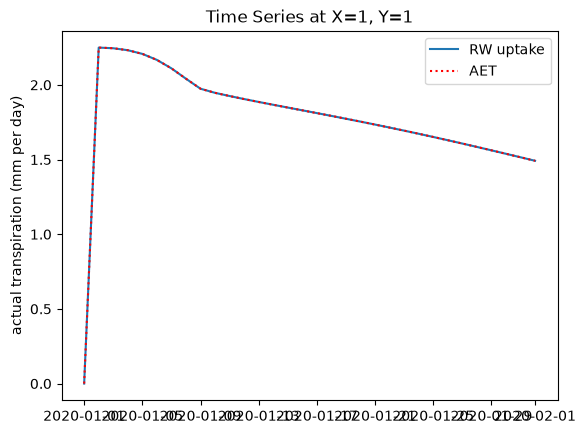

In [10]:
aet_file_name = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Tutorials\Tutorial_2\Vegetation_Vadose_Model\VV_Model.she - Result Files\VV_Model_ET_UzCells.dfs2'

# Open the file to get a Dfs2 object (metadata is available but data isn't loaded yet)
dfs = Dfs2(aet_file_name)

# Inspect file properties (e.g., number of time steps, items)
print(f"Number of time steps: {dfs.n_timesteps}")
print(f"Item names: {[item.name for item in dfs.items]}")

my_item = r'actual transpiration' # define the item you are interested in


# Read the Dataset (ds)
ds = mikeio.read(aet_file_name, items=[my_item])
# extract the time indices from the file
time_array_datetime = ds.time.values
unit = repr(ds[my_item].unit) # get the unit - take not of the use of repr here - unit itself may be an internal code

# Get the DataArray for the item of interest
data_array = ds[my_item]
# The shape of the underlying data is (time, y, x)
print(data_array.shape) # Example output: (500, 100, 80)
aet_time_series_values = data_array.values[:, y_idx, x_idx]
fig, ax = plt.subplots()
ax.plot(time_array_datetime, total_rw_uptake, label = 'RW uptake')
ax.plot(time_array_datetime, aet_time_series_values, 'r:', label = 'AET')
ax.set_ylabel(f"{my_item}" + ' (' + unit + ')')
ax.set_title(f"Time Series at X={x_idx}, Y={y_idx}")
ax.legend()
plt.show()

As expected, root water uptake and actual ET are identical.